# Treino — Baseline v1: TF-IDF + Logistic Regression

Treina e avalia o primeiro modelo de classificação binária sobre o `dataset_final_treino_v1.csv`.

**Entrada:** `texto_principal` (texto limpo)
**Alvo:** `label` (0 = negativo/falso, 1 = positivo/real)

**Pipeline:**
1. Limpeza textual (remoção de artefatos de RSS, separadores)
2. TF-IDF Vectorizer
3. Logistic Regression

**Regras:**
- Apenas `texto_principal` entra como feature
- Split 80/20 estratificado por `label_detalhe`
- Seed 42 em todas as etapas com aleatoriedade
- Não altera o dataset nem nenhum outro arquivo

## Bibliotecas

In [17]:
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from pathlib import Path
from datetime import datetime

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## Configuração

In [18]:
SEED        = 42
TEST_SIZE   = 0.20

CAMINHO_DATASET = Path('../dados/dataset_unificado/final/dataset_final_treino_v1.csv')
PASTA_MODELOS   = Path('../modelos')
PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

NOME_MODELO = 'baseline_tfidf_logreg_v1'
CAMINHO_MODELO = PASTA_MODELOS / f'{NOME_MODELO}.joblib'
CAMINHO_META   = PASTA_MODELOS / f'{NOME_MODELO}_meta.json'

print(f'Dataset : {CAMINHO_DATASET}')
print(f'Modelo  : {CAMINHO_MODELO}')
print(f'Meta    : {CAMINHO_META}')

Dataset : ..\dados\dataset_unificado\final\dataset_final_treino_v1.csv
Modelo  : ..\modelos\baseline_tfidf_logreg_v1.joblib
Meta    : ..\modelos\baseline_tfidf_logreg_v1_meta.json


## Carregamento do dataset

In [19]:
df = pd.read_csv(CAMINHO_DATASET, encoding='utf-8-sig', dtype=str)
df['label'] = df['label'].astype(int)

print(f'Shape: {df.shape}')
print(f'\nDistribuição de label:')
print(df['label'].value_counts().to_string())
print(f'\nDistribuição de label_detalhe:')
print(df['label_detalhe'].value_counts().to_string())

Shape: (800, 10)

Distribuição de label:
label
0    400
1    400

Distribuição de label_detalhe:
label_detalhe
NOTICIA_REAL        374
FALSO               260
ENGANOSO            120
GFC_VERDADEIRO       26
FORA_DE_CONTEXTO     20


## Limpeza textual

Remove artefatos de RSS e separadores que funcionam como assinatura de fonte,
não como conteúdo semântico. A análise do dataset identificou que a palavra
"leia" aparece 57× nos positivos e 0× nos negativos — artefato de montagem
do `titulo_resumo` que vazaria informação de fonte para o modelo.

In [20]:
# Padrões de artefatos a remover (ordem importa: mais específico primeiro)
_ARTEFATOS = [
    r'leia\s+a\s+reportagem\s+completa',
    r'leia\s+tamb[eé]m',
    r'leia\s+mais',
    r'\bleia\b',
    r'(?:^|\s)[\-\–\—]+(?:\s|$)',   # separadores —, –, -
    r'\s*[\|]\s*',                   # pipes usados como separadores
    r'\s{2,}',                        # múltiplos espaços
]

_RE_ARTEFATOS = re.compile(
    '|'.join(_ARTEFATOS),
    flags=re.IGNORECASE
)


def limpar_texto(texto: str) -> str:
    if not isinstance(texto, str):
        return ''
    t = texto.lower()
    t = _RE_ARTEFATOS.sub(' ', t)
    t = t.strip()
    return t


df['texto_limpo'] = df['texto_principal'].apply(limpar_texto)

# Verificação: quantas ocorrências de 'leia' restam
leia_antes = df['texto_principal'].str.lower().str.contains(r'\bleia\b', regex=True).sum()
leia_depois = df['texto_limpo'].str.contains(r'\bleia\b', regex=True).sum()
print(f'Ocorrências de "leia" antes da limpeza : {leia_antes}')
print(f'Ocorrências de "leia" após a limpeza   : {leia_depois}')

# Amostra de textos antes e depois
mask_leia = df['texto_principal'].str.lower().str.contains(r'\bleia\b', regex=True, na=False)
print(f'\nExemplos (antes → depois):')
for _, r in df[mask_leia].head(3).iterrows():
    print(f'  ANTES : {repr(r["texto_principal"][:120])}')
    print(f'  DEPOIS: {repr(r["texto_limpo"][:120])}')
    print()

Ocorrências de "leia" antes da limpeza : 57
Ocorrências de "leia" após a limpeza   : 0

Exemplos (antes → depois):
  ANTES : "Fundo nos EUA do caso 'Dark Horse' é controlado por aliados de Eduardo Bolsonaro — O fundo Havengate Development Fund, u"
  DEPOIS: "fundo nos eua do caso 'dark horse' é controlado por aliados de eduardo bolsonaro o fundo havengate development fund, usa"

  ANTES : 'PGR denuncia Zema sob acusação de calúnia contra Gilmar Mendes — A PGR (Procuradoria-Geral da República) denunciou o ex-'
  DEPOIS: 'pgr denuncia zema sob acusação de calúnia contra gilmar mendes a pgr (procuradoria-geral da república) denunciou o ex-go'

  ANTES : 'Datafolha: 9 de 10 eleitores dizem não se arrepender de voto em Lula ou Bolsonaro em 2022 — Passados quase três anos e m'
  DEPOIS: 'datafolha: 9 de 10 eleitores dizem não se arrepender de voto em lula ou bolsonaro em 2022 passados quase três anos e mei'



## Divisão treino / teste

In [21]:
X = df['texto_limpo'].values
y = df['label'].values
grupos = df['label_detalhe'].values   # estratificação por subclasse

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(sss.split(X, grupos))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

df_test = df.iloc[test_idx].copy()

print(f'Treino : {len(X_train)} amostras')
print(f'Teste  : {len(X_test)} amostras')
print(f'\nDistribuição no treino:')
for v, c in zip(*np.unique(y_train, return_counts=True)):
    print(f'  label={v}: {c}')
print(f'\nDistribuição no teste:')
for v, c in zip(*np.unique(y_test, return_counts=True)):
    print(f'  label={v}: {c}')
print(f'\nDistribuição de label_detalhe no teste:')
print(df_test['label_detalhe'].value_counts().to_string())

Treino : 640 amostras
Teste  : 160 amostras

Distribuição no treino:
  label=0: 320
  label=1: 320

Distribuição no teste:
  label=0: 80
  label=1: 80

Distribuição de label_detalhe no teste:
label_detalhe
NOTICIA_REAL        75
FALSO               52
ENGANOSO            24
GFC_VERDADEIRO       5
FORA_DE_CONTEXTO     4


## Pipeline: TF-IDF + Logistic Regression

In [22]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.90,
        analyzer='word',
    )),
    ('clf', LogisticRegression(
        C=1.0,
        solver='lbfgs',
        max_iter=1_000,
        class_weight='balanced',
        random_state=SEED,
    )),
])

pipeline.fit(X_train, y_train)
print('Modelo treinado.')
print(f'Features TF-IDF: {len(pipeline["tfidf"].vocabulary_)}')

Modelo treinado.
Features TF-IDF: 2640


## Avaliação no conjunto de teste

In [23]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

acc      = accuracy_score(y_test, y_pred)
prec     = precision_score(y_test, y_pred, zero_division=0)
rec      = recall_score(y_test, y_pred, zero_division=0)
f1       = f1_score(y_test, y_pred, zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
roc_auc  = roc_auc_score(y_test, y_proba)

print('=' * 50)
print('MÉTRICAS NO CONJUNTO DE TESTE')
print('=' * 50)
print(f'  Acurácia          : {acc:.4f}')
print(f'  Precisão (pos)    : {prec:.4f}')
print(f'  Recall (pos)      : {rec:.4f}')
print(f'  F1-score (pos)    : {f1:.4f}')
print(f'  F1-score (macro)  : {f1_macro:.4f}')
print(f'  ROC-AUC           : {roc_auc:.4f}')

print('\nClassification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['0-negativo', '1-positivo'],
    zero_division=0
))

MÉTRICAS NO CONJUNTO DE TESTE
  Acurácia          : 0.8625
  Precisão (pos)    : 0.9394
  Recall (pos)      : 0.7750
  F1-score (pos)    : 0.8493
  F1-score (macro)  : 0.8614
  ROC-AUC           : 0.9359

Classification Report:
              precision    recall  f1-score   support

  0-negativo       0.81      0.95      0.87        80
  1-positivo       0.94      0.78      0.85        80

    accuracy                           0.86       160
   macro avg       0.87      0.86      0.86       160
weighted avg       0.87      0.86      0.86       160



## Matriz de confusão

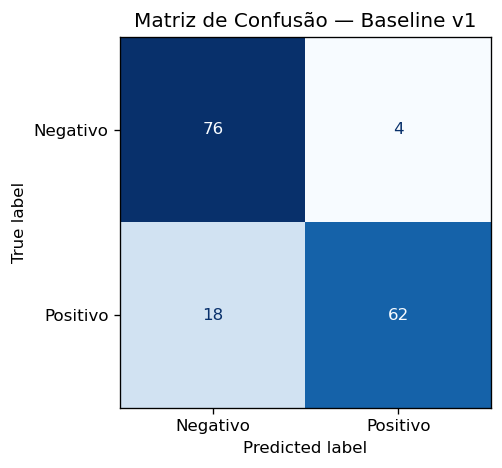

TN=76  FP=4  FN=18  TP=62
Falsos positivos (negativo classificado como positivo): 4
Falsos negativos (positivo classificado como negativo): 18


In [24]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo', 'Positivo'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão — Baseline v1', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Falsos positivos (negativo classificado como positivo): {fp}')
print(f'Falsos negativos (positivo classificado como negativo): {fn}')

## Erros por `label_detalhe`

Identifica em quais subclasses o modelo erra com mais frequência.

In [25]:
df_test = df_test.copy()
df_test['pred']  = y_pred
df_test['proba'] = y_proba
df_test['erro']  = df_test['label'] != df_test['pred']

print('Erros por label_detalhe:')
erros_por_classe = (
    df_test.groupby('label_detalhe')
    .agg(total=('erro', 'count'), erros=('erro', 'sum'))
    .assign(taxa_erro=lambda d: (d['erros'] / d['total']).round(3))
    .sort_values('taxa_erro', ascending=False)
)
print(erros_por_classe.to_string())

Erros por label_detalhe:
                  total  erros  taxa_erro
label_detalhe                            
GFC_VERDADEIRO        5      2      0.400
NOTICIA_REAL         75     16      0.213
FALSO                52      4      0.077
ENGANOSO             24      0      0.000
FORA_DE_CONTEXTO      4      0      0.000


## Top coeficientes do modelo

In [26]:
feat_names = pipeline['tfidf'].get_feature_names_out()
coefs      = pipeline['clf'].coef_[0]
TOP_N      = 25

idx_pos = np.argsort(coefs)[-TOP_N:][::-1]
idx_neg = np.argsort(coefs)[:TOP_N]

print(f'TOP {TOP_N} tokens → POSITIVO (coef mais alto = mais indicativo de real/verdadeiro):')
for i in idx_pos:
    print(f'  {feat_names[i]:<35}  coef={coefs[i]:+.4f}')

print(f'\nTOP {TOP_N} tokens → NEGATIVO (coef mais baixo = mais indicativo de falso/enganoso):')
for i in idx_neg:
    print(f'  {feat_names[i]:<35}  coef={coefs[i]:+.4f}')

TOP 25 tokens → POSITIVO (coef mais alto = mais indicativo de real/verdadeiro):
  sobre                                coef=+1.7209
  vorcaro                              coef=+1.4729
  da                                   coef=+1.4481
  flávio                               coef=+1.3387
  filme                                coef=+1.1399
  entre                                coef=+1.0072
  05                                   coef=+0.9779
  com                                  coef=+0.9245
  como                                 coef=+0.9177
  ex                                   coef=+0.8646
  ao                                   coef=+0.8642
  2026                                 coef=+0.8613
  pré                                  coef=+0.7893
  ciro                                 coef=+0.7311
  daniel vorcaro                       coef=+0.7269
  daniel                               coef=+0.7269
  feira                                coef=+0.6897
  master                            

## Visualização dos coeficientes

Gráfico de barras horizontais para os 20 tokens mais discriminantes em cada direção.

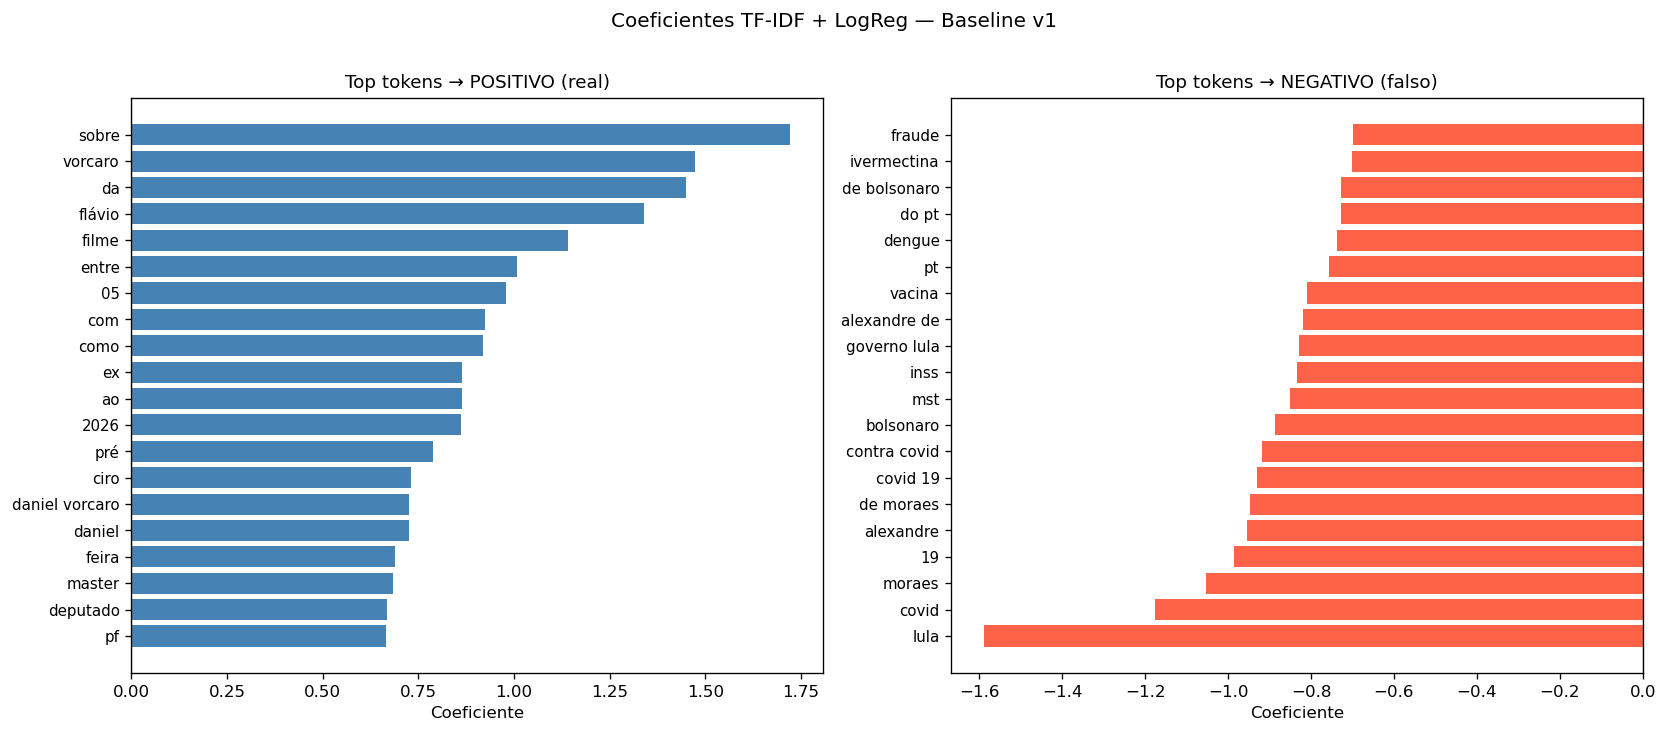

In [27]:
TOP_VIZ = 20

top_pos_names  = feat_names[np.argsort(coefs)[-TOP_VIZ:][::-1]]
top_pos_coefs  = coefs[np.argsort(coefs)[-TOP_VIZ:][::-1]]
top_neg_names  = feat_names[np.argsort(coefs)[:TOP_VIZ]]
top_neg_coefs  = coefs[np.argsort(coefs)[:TOP_VIZ]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(range(TOP_VIZ), top_pos_coefs[::-1], color='steelblue')
ax1.set_yticks(range(TOP_VIZ))
ax1.set_yticklabels(top_pos_names[::-1], fontsize=9)
ax1.set_title('Top tokens → POSITIVO (real)', fontsize=11)
ax1.set_xlabel('Coeficiente')
ax1.axvline(0, color='gray', linewidth=0.8)

ax2.barh(range(TOP_VIZ), top_neg_coefs, color='tomato')
ax2.set_yticks(range(TOP_VIZ))
ax2.set_yticklabels(top_neg_names, fontsize=9)
ax2.set_title('Top tokens → NEGATIVO (falso)', fontsize=11)
ax2.set_xlabel('Coeficiente')
ax2.axvline(0, color='gray', linewidth=0.8)

plt.suptitle('Coeficientes TF-IDF + LogReg — Baseline v1', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Inspeção de erros

Mostra os erros de classificação ordenados por probabilidade (os mais confiantes primeiro),
para identificar padrões de falha do modelo.

In [28]:
erros = df_test[df_test['erro']].sort_values('proba', ascending=False).copy()

print(f'Total de erros: {len(erros)} de {len(df_test)} ({100*len(erros)/len(df_test):.1f}%)')

print('\n--- Falsos Positivos (negativo classificado como positivo) ---')
fp_df = erros[(erros['label'] == 0) & (erros['pred'] == 1)]
print(f'  Total: {len(fp_df)}')
for i, (_, r) in enumerate(fp_df.head(10).iterrows()):
    print(f'\n  [{i+1}] label_detalhe={r["label_detalhe"]}  proba={r["proba"]:.3f}  portal={r["portal_origem"]}')
    print(f'       {repr(r["texto_principal"][:150])}')

print('\n--- Falsos Negativos (positivo classificado como negativo) ---')
fn_df = erros[(erros['label'] == 1) & (erros['pred'] == 0)]
print(f'  Total: {len(fn_df)}')
for i, (_, r) in enumerate(fn_df.head(10).iterrows()):
    print(f'\n  [{i+1}] label_detalhe={r["label_detalhe"]}  proba={r["proba"]:.3f}  portal={r["portal_origem"]}')
    print(f'       {repr(r["texto_principal"][:150])}')

Total de erros: 22 de 160 (13.8%)

--- Falsos Positivos (negativo classificado como positivo) ---
  Total: 4

  [1] label_detalhe=FALSO  proba=0.624  portal=AOS_FATOS
       'Foto mostra Trump gritando com Lula durante reunião na Casa Branca'

  [2] label_detalhe=FALSO  proba=0.602  portal=UOL_NOTÍCIAS
       'Como assim o assassino da Mariele não pode ser preso? Moraes manda soltar Chiquinho Brazão e quer prender Bolsonaro'

  [3] label_detalhe=FALSO  proba=0.524  portal=ESTADÃO
       'Tarcísio de Freitas divulga link para consulta e saque de indenização por vazamento de dados'

  [4] label_detalhe=FALSO  proba=0.516  portal=ESTADÃO
       'Polícia Militar confirma 2 milhões de pessoas na Avenida Paulista.'

--- Falsos Negativos (positivo classificado como negativo) ---
  Total: 18

  [1] label_detalhe=NOTICIA_REAL  proba=0.493  portal=G1_POLITICA
       'Com Lula prestes a encontrar Trump, Alckmin fala em buscar parcerias com EUA'

  [2] label_detalhe=NOTICIA_REAL  proba=0.490  port

## Salvamento do modelo e metadados

In [29]:
joblib.dump(pipeline, CAMINHO_MODELO)
print(f'Modelo salvo em: {CAMINHO_MODELO}')

meta = {
    'nome_modelo'        : NOME_MODELO,
    'data_treino'        : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset'            : str(CAMINHO_DATASET.name),
    'seed'               : SEED,
    'test_size'          : TEST_SIZE,
    'n_treino'           : int(len(X_train)),
    'n_teste'            : int(len(X_test)),
    'estratificacao'     : 'label_detalhe',
    'features'           : ['texto_principal'],
    'tfidf_max_features' : 5000,
    'tfidf_ngram_range'  : [1, 2],
    'tfidf_sublinear_tf' : True,
    'tfidf_min_df'       : 2,
    'tfidf_max_df'       : 0.90,
    'logreg_C'           : 1.0,
    'logreg_solver'      : 'lbfgs',
    'logreg_class_weight': 'balanced',
    'n_features_tfidf'   : int(len(pipeline['tfidf'].vocabulary_)),
    'metricas_teste': {
        'acuracia'        : round(acc, 4),
        'precisao_pos'    : round(prec, 4),
        'recall_pos'      : round(rec, 4),
        'f1_pos'          : round(f1, 4),
        'f1_macro'        : round(f1_macro, 4),
        'roc_auc'         : round(roc_auc, 4),
    },
}

with open(CAMINHO_META, 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f'Metadados salvos em: {CAMINHO_META}')
print('\nMétricas registradas:')
for k, v in meta['metricas_teste'].items():
    print(f'  {k}: {v}')

Modelo salvo em: ..\modelos\baseline_tfidf_logreg_v1.joblib
Metadados salvos em: ..\modelos\baseline_tfidf_logreg_v1_meta.json

Métricas registradas:
  acuracia: 0.8625
  precisao_pos: 0.9394
  recall_pos: 0.775
  f1_pos: 0.8493
  f1_macro: 0.8614
  roc_auc: 0.9359


## Verificação de carregamento

Confirma que o modelo salvo pode ser carregado e produz as mesmas previsões.

In [30]:
modelo_carregado = joblib.load(CAMINHO_MODELO)
y_pred_check = modelo_carregado.predict(X_test)

assert (y_pred_check == y_pred).all(), 'ERRO: previsões divergem após recarregamento!'
print('Modelo recarregado com sucesso. Previsões idênticas.')

# Exemplos de predição ao vivo
exemplos = [
    'Lula perdeu todas as eleições com votação manual.',
    'Congresso aprova projeto que regulamenta uso de inteligência artificial no Brasil.',
    'Vacina da Covid contém chip para rastrear a população.',
    'Senado aprova aumento do salário mínimo para 2026.',
    'Senado aprova aumento do salario minimo para 2026.',
]
preds = modelo_carregado.predict(exemplos)
probas = modelo_carregado.predict_proba(exemplos)[:, 1]

print('\nExemplos de predição:')
for txt, pred, prob in zip(exemplos, preds, probas):
    classe = 'POSITIVO/REAL' if pred == 1 else 'NEGATIVO/FALSO'
    print(f'  [{classe}  prob={prob:.3f}]  {repr(txt[:80])}')

Modelo recarregado com sucesso. Previsões idênticas.

Exemplos de predição:
  [NEGATIVO/FALSO  prob=0.355]  'Lula perdeu todas as eleições com votação manual.'
  [POSITIVO/REAL  prob=0.618]  'Congresso aprova projeto que regulamenta uso de inteligência artificial no Brasi'
  [NEGATIVO/FALSO  prob=0.310]  'Vacina da Covid contém chip para rastrear a população.'
  [NEGATIVO/FALSO  prob=0.441]  'Senado aprova aumento do salário mínimo para 2026.'
  [POSITIVO/REAL  prob=0.567]  'Senado aprova aumento do salario minimo para 2026.'


## Observação — Sensibilidade à Acentuação

### Achado

Durante a validação do baseline foi identificado que a entrada:

```
"Senado aprova aumento do salário mínimo para 2026."
```

produz resultados **diferentes** dependendo de o texto estar corretamente acentuado ou não:

| Entrada | prob(positivo) | Classe prevista |
|---|---|---|
| Com acentos: `"...salário mínimo..."` | 0.441 | NEGATIVO/FALSO |
| Sem acentos: `"...salario minimo..."` | 0.567 | POSITIVO/REAL |

### Causa

O pré-processamento da v1 faz *lowercase* mas **preserva acentuação**. Portanto o vocabulário
TF-IDF trata `"salário"` e `"salario"` como tokens distintos:

- `"salário"` está no vocabulário com coeficiente **−0.47** (associado à classe negativa)
- `"salário mínimo"` (bigrama) está no vocabulário com coeficiente **−0.33**
- `"salario"` e `"salario minimo"` (sem acento) são tokens fora do vocabulário → contribuição zero

Quando a acentuação está ausente, esses tokens negativos não ativam e os tokens
remanescentes (`"senado"`, `"aprova"`, `"2026"`) empurram levemente para o lado positivo.

### O notebook não tem outputs conflitantes

Os outputs preservados neste notebook são da execução via Jupyter com os textos
**corretamente acentuados** e são, portanto, a referência correta.
A divergência reportada veio de um script auxiliar de diagnóstico (já removido) que
usava textos sem acentos — inputs diferentes para o mesmo modelo produzem resultados diferentes,
o que é comportamento esperado.

### Melhoria planejada para a V2

Adicionar normalização de acentos no pré-processamento (`texto_limpo`):

```python
import unicodedata

def remover_acentos(texto: str) -> str:
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
```

Com isso, `"salário"` e `"salario"` se tornam o mesmo token no vocabulário,
eliminando a sensibilidade à grafia do usuário ao usar o modelo em produção.

In [31]:
import sklearn, unicodedata

# ── Confirma consistência: pipeline em memória == modelo carregado do joblib ──
coef_mem = pipeline.named_steps['clf'].coef_[0]
coef_job = modelo_carregado.named_steps['clf'].coef_[0]
vocab_identico = (
    pipeline.named_steps['tfidf'].vocabulary_ ==
    modelo_carregado.named_steps['tfidf'].vocabulary_
)

assert np.allclose(coef_mem, coef_job), 'ERRO: coeficientes divergem entre mem e joblib!'
assert vocab_identico, 'ERRO: vocabulários divergem entre mem e joblib!'
print('Consistência confirmada: pipeline em memória e joblib são idênticos.')
print(f'  classes_ = {pipeline.named_steps["clf"].classes_}')
print(f'  predict_proba[:, 1] → probabilidade da classe 1 (positivo/real)')
print(f'  scikit-learn em uso : {sklearn.__version__}')

# ── Demonstração: acentuado vs não-acentuado ──────────────────────────────────
def remover_acentos(texto: str) -> str:
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

casos = [
    'Lula perdeu todas as eleições com votação manual.',
    'Vacina da Covid contém chip para rastrear a população.',
    'Senado aprova aumento do salário mínimo para 2026.',
    'Congresso aprova projeto de regulamentação de IA no Brasil.',
]

print('\nDemonstração de sensibilidade à acentuação (mesmo modelo, inputs distintos):')
print(f'  {"Texto (truncado)":<50} {"prob(acentuado)":>16} {"prob(sem acento)":>16} {"diverge?":>8}')
print('  ' + '-'*94)
for t in casos:
    t_sem = remover_acentos(t.lower())
    t_com = t.lower()
    p_com = pipeline.predict_proba([limpar_texto(t)])[0][1]
    p_sem = pipeline.predict_proba([limpar_texto(t_sem)])[0][1]
    muda_classe = (p_com >= 0.5) != (p_sem >= 0.5)
    flag = '<-- MUDA CLASSE' if muda_classe else ''
    print(f'  {t[:50]:<50} {p_com:>16.4f} {p_sem:>16.4f} {flag}')

# ── Tokens problemáticos no vocabulário ──────────────────────────────────────
print('\nTokens de "salário/mínimo" no vocabulário TF-IDF (v1):')
vocab = pipeline.named_steps['tfidf'].vocabulary_
coefs = pipeline.named_steps['clf'].coef_[0]
for tok in sorted(vocab):
    if any(k in tok for k in ('salário', 'mínimo', 'salario', 'minimo')):
        idx  = vocab[tok]
        coef = coefs[idx]
        nota = '← em vocab' if tok == tok else ''
        print(f'  {repr(tok):<28}  idx={idx:<5}  coef={coef:+.4f}')
print('  (tokens sem acento "salario"/"minimo" ausentes → OOV → coef=0 implícito)')

Consistência confirmada: pipeline em memória e joblib são idênticos.
  classes_ = [0 1]
  predict_proba[:, 1] → probabilidade da classe 1 (positivo/real)
  scikit-learn em uso : 1.5.1

Demonstração de sensibilidade à acentuação (mesmo modelo, inputs distintos):
  Texto (truncado)                                    prob(acentuado) prob(sem acento) diverge?
  ----------------------------------------------------------------------------------------------
  Lula perdeu todas as eleições com votação manual.            0.3551           0.3339 
  Vacina da Covid contém chip para rastrear a popula           0.3104           0.3058 
  Senado aprova aumento do salário mínimo para 2026.           0.4407           0.5667 <-- MUDA CLASSE
  Congresso aprova projeto de regulamentação de IA n           0.5871           0.5871 

Tokens de "salário/mínimo" no vocabulário TF-IDF (v1):
  'ao salário'                  idx=190    coef=-0.2339
  'mínimo'                      idx=1660   coef=-0.2596
  'mínimo 